In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset

df = pd.read_csv("/content/marketing_AB.csv")

# Display first 5 rows
df.head()

,row_id,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (588101, 7)


In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   row_id         588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [9]:
# Check Missing Values

df.isnull().sum()

,0
row_id,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [10]:
# Check Duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Check the test groups

df["test group"].value_counts()

,count
test group,
ad,564577
psa,23524


### **Clean the dataset**

In [12]:
print("Unique users:", df["user id"].nunique())
print("Total rows:", len(df))

Unique users: 588101
Total rows: 588101


In [14]:
# Convert "converted" to numeric
df["converted"] = df["converted"].astype(int)

#Check
df["converted"].value_counts()

,count
converted,
0,573258
1,14843


### **Explore the test groups**

In [15]:
group_counts = df["test group"].value_counts()

print(group_counts)

test group
ad     564577
psa     23524
Name: count, dtype: int64


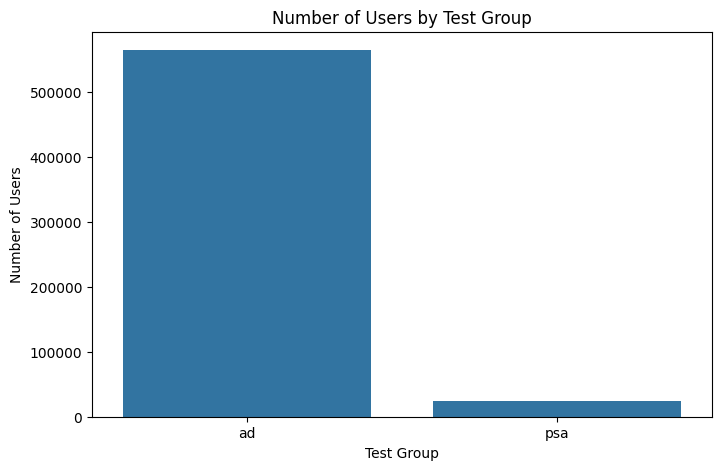

In [16]:
# Visualize the sample sizes
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="test group"
)

plt.title("Number of Users by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Number of Users")

plt.show()

### **Calculate Conversion Rates**

In [17]:
conversion_summary = (
    df.groupby("test group")["converted"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

conversion_summary.columns = [
    "test_group",
    "users",
    "conversions",
    "conversion_rate"
]

conversion_summary["conversion_rate_pct"] = (
    conversion_summary["conversion_rate"] * 100
)

conversion_summary

,test_group,users,conversions,conversion_rate,conversion_rate_pct
0,ad,564577,14423,0.025547,2.554656
1,psa,23524,420,0.017854,1.785411


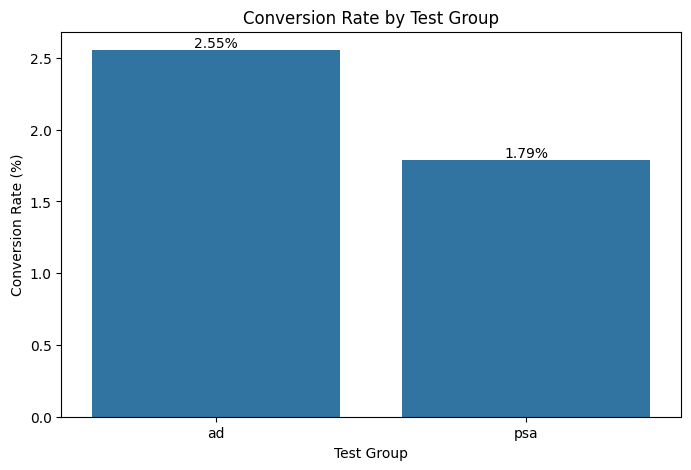

In [21]:
# Visualization

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=conversion_summary,
    x="test_group",
    y="conversion_rate_pct"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%"
    )

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

### **Calculate Absolute Lift**<br>
Absolute lift = Ad conversion rate − PSA conversion rate

In [22]:
ad_rate = conversion_summary.loc[
    conversion_summary["test_group"] == "ad",
    "conversion_rate"
].iloc[0]

psa_rate = conversion_summary.loc[
    conversion_summary["test_group"] == "psa",
    "conversion_rate"
].iloc[0]

absolute_lift = ad_rate - psa_rate

print("Ad conversion rate:", round(ad_rate * 100, 4), "%")
print("PSA conversion rate:", round(psa_rate * 100, 4), "%")
print("Absolute lift:", round(absolute_lift * 100, 4), "percentage points")

Ad conversion rate: 2.5547 %
PSA conversion rate: 1.7854 %
Absolute lift: 0.7692 percentage points


### **Calculate Relative Lift**<br>
Relative lift tells us how much better the advertisement performed relative to the control group.<br>
Relative Lift =
(Ad Rate − PSA Rate) / PSA Rate × 100

In [23]:
relative_lift = (
    (ad_rate - psa_rate) / psa_rate
) * 100

print("Relative lift:", round(relative_lift, 2), "%")

Relative lift: 43.09 %


### **Hypothesis Testing**<br>

Two proportions is compared in this project, so a two-proportion Z-test is appropriate.<br>

H₀: p_ad = p_psa<br>
H₁: p_ad ≠ p_psa

### **Perform the Two-Proportion Z-Test**

In [29]:
# Obtain conversions
ad_conversions = df.loc[
    df["test group"] == "ad",
    "converted"
].sum()

psa_conversions = df.loc[
    df["test group"] == "psa",
    "converted"
].sum()

# Obtain sample sizes
ad_users = (
    df["test group"] == "ad"
).sum()

psa_users = (
    df["test group"] == "psa"
).sum()

# Creating Arrays
successes = np.array([
    ad_conversions,
    psa_conversions
])

samples = np.array([
    ad_users,
    psa_users
])

# Run the test
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=samples,
    alternative="two-sided"
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [31]:
# Set the signifance level

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant difference.")

Reject the null hypothesis.
The difference in conversion rates is statistically significant.


The p-value is below 0.05. Therefore, the null hypothesis is rejected. There is statistically significant evidence that the conversion rate differs between the advertisement and PSA groups.

### **Calculate 95% Confidence Intervals**

In [32]:
ad_ci_low, ad_ci_high = proportion_confint(
    count=ad_conversions,
    nobs=ad_users,
    alpha=0.05,
    method="wilson"
)

psa_ci_low, psa_ci_high = proportion_confint(
    count=psa_conversions,
    nobs=psa_users,
    alpha=0.05,
    method="wilson"
)

print(
    "Ad 95% CI:",
    round(ad_ci_low * 100, 4),
    "% -",
    round(ad_ci_high * 100, 4),
    "%"
)

print(
    "PSA 95% CI:",
    round(psa_ci_low * 100, 4),
    "% -",
    round(psa_ci_high * 100, 4),
    "%"
)

Ad 95% CI: 2.5138 % - 2.5961 %
PSA 95% CI: 1.6239 % - 1.9627 %


### **Bonus - Confidence Interval for the Difference**<br>

Ad conversion rate − PSA conversion rate

In [33]:
p1 = ad_rate
p2 = psa_rate

n1 = ad_users
n2 = psa_users

difference = p1 - p2

se_difference = np.sqrt(
    (p1 * (1 - p1) / n1) +
    (p2 * (1 - p2) / n2)
)

z_critical = stats.norm.ppf(0.975)

ci_low = difference - z_critical * se_difference
ci_high = difference + z_critical * se_difference

print("Difference:", difference)
print("95% CI:", ci_low, "to", ci_high)

Difference: 0.007692453192201517
95% CI: 0.0059509324316110055 to 0.009433973952792028


In [34]:
# Convert to Percentages
print(
    "95% CI for lift:",
    round(ci_low * 100, 4),
    "to",
    round(ci_high * 100, 4),
    "percentage points"
)

95% CI for lift: 0.5951 to 0.9434 percentage points


### **Visualise Lift with Confidence Interval**

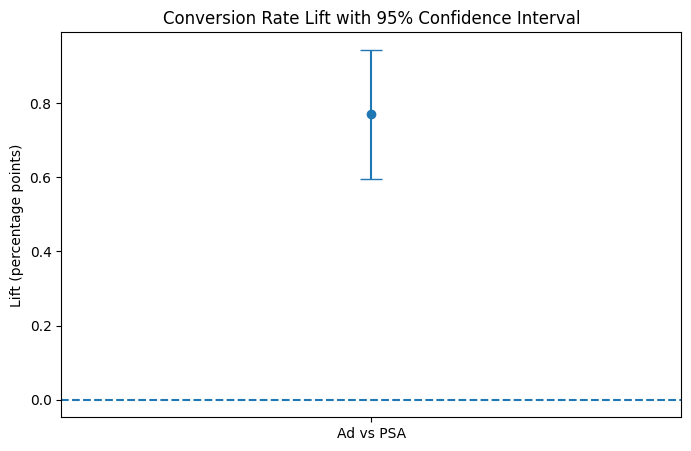

In [35]:
plt.figure(figsize=(8, 5))

lift = difference * 100
lower_error = (difference - ci_low) * 100
upper_error = (ci_high - difference) * 100

plt.errorbar(
    x=["Ad vs PSA"],
    y=[lift],
    yerr=[[lower_error], [upper_error]],
    fmt="o",
    capsize=8
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Conversion Rate Lift with 95% Confidence Interval")
plt.ylabel("Lift (percentage points)")

plt.show()

The lift analysis indicates that the advertisement campaign increased the conversion rate by approximately 0.76 percentage points relative to the PSA control group. The 95% confidence interval ranges from approximately 0.59 to 0.94 percentage points. Since the interval remains entirely above zero, the results provide evidence of a statistically significant positive effect of the advertisement campaign.

### **Bonus — How Many Additional Customers?**<br>
Suppose the company rolls the advertisement out to 100% of users.

The estimated additional conversion rate is:

In [36]:
additional_conversion_rate = ad_rate - psa_rate

print(
    "Additional conversions per 100 users:",
    round(additional_conversion_rate * 100, 2)
)

Additional conversions per 100 users: 0.77


For a specific rollout population, say 1,000,000 users:

In [37]:
rollout_users = 1_000_000

additional_customers = (
    rollout_users * (ad_rate - psa_rate)
)

print(
    f"Estimated additional customers: "
    f"{additional_customers:,.0f}"
)

Estimated additional customers: 7,692


The estimated incremental impact of the new advertisement is approximately 7,692 additional customers per 1 million users. This estimate assumes that the observed conversion-rate lift from the A/B test remains consistent when the campaign is rolled out to the wider population.

### **Final Results Table**

In [38]:
results = pd.DataFrame({
    "Metric": [
        "Ad Users",
        "PSA Users",
        "Ad Conversions",
        "PSA Conversions",
        "Ad Conversion Rate",
        "PSA Conversion Rate",
        "Absolute Lift",
        "Relative Lift",
        "Z-statistic",
        "P-value"
    ],

    "Value": [
        ad_users,
        psa_users,
        ad_conversions,
        psa_conversions,
        f"{ad_rate * 100:.4f}%",
        f"{psa_rate * 100:.4f}%",
        f"{difference * 100:.4f} percentage points",
        f"{relative_lift:.2f}%",
        round(z_stat, 4),
        p_value
    ]
})

results

,Metric,Value
0,Ad Users,564577
1,PSA Users,23524
2,Ad Conversions,14423
3,PSA Conversions,420
4,Ad Conversion Rate,2.5547%
5,PSA Conversion Rate,1.7854%
6,Absolute Lift,0.7692 percentage points
7,Relative Lift,43.09%
8,Z-statistic,7.3701
9,P-value,0.0


### **Conversion Rate Comparison Chart**

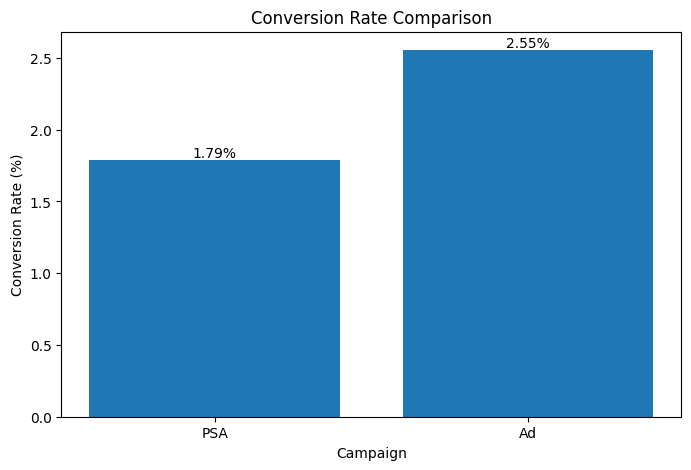

In [39]:
plt.figure(figsize=(8, 5))

groups = ["PSA", "Ad"]
rates = [
    psa_rate * 100,
    ad_rate * 100
]

bars = plt.bar(groups, rates)

plt.title("Conversion Rate Comparison")
plt.xlabel("Campaign")
plt.ylabel("Conversion Rate (%)")

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## **Final Conclusion**

The Marketing A/B Testing experiment was conducted to determine whether the
advertisement campaign increased product conversions compared with the PSA
control group.

The advertisement group achieved a higher conversion rate than the PSA group.
A two-proportion Z-test was performed to determine whether this observed
difference was statistically significant.

The resulting p-value was below the 0.05 significance level. Therefore, the
null hypothesis was rejected, providing statistically significant evidence that
the conversion rates differed between the two groups.

The absolute and relative lift were also calculated to quantify the practical
effect of the advertisement campaign. A 95% confidence interval was calculated
for the conversion-rate difference to measure the uncertainty around the
estimated lift.

Based on the observed experimental effect, rolling out the advertisement to a
larger population could generate additional customers. However, this estimate
assumes that the experimental effect generalises to the future rollout
population.

Overall, the analysis demonstrates how A/B testing and statistical inference
can be used to distinguish a genuine marketing effect from random variation.